[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nikbaya/smartbiomed_practicals_2026/blob/main/session2/run.ipynb)

# Session 2: Interpreting GWAS — Practical

**Timing**: 45 minutes.
- Parts 1–2 (Manhattan + QQ plots): ~30 minutes.
- Challenge questions: for fast finishers.

**Data**: We now use **real genome-wide Pan-UKB summary statistics** (EUR) for three traits —
LDL cholesterol (continuous), chronic ischaemic heart disease (binary), and body mass index
(highly polygenic) — for the Manhattan, QQ, trumpet and pleiotropy plots. We also bundle
**Genebass whole-exome** single-variant results for BMI (for the Miami-plot challenge). The setup
cell also re-runs the Session 1 *simulated* GWAS, which we still use for the analyses that need
individual-level genotypes (null-QQ contrast).

**Setup**: Run the setup cell once at the top (loads real sumstats + re-runs the simulated
GWAS, ~30s) before any exercises.


In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# SETUP — Run this cell once. No modification needed.
# Loads the pre-generated GWAS dataset (or falls back to a synthetic version).
# ─────────────────────────────────────────────────────────────────────────────
import os, numpy as np, pandas as pd
from scipy import stats, special
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings; warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 80, 'font.size': 11})

# Locate the data directory, downloading from GitHub if needed (e.g. on Colab).
import os, urllib.request
_NEED = ['gwas_data.npz', 'fly_data.csv']
_LFS  = {'gwas_data.npz', 'sumstats_real.npz', 'pca_data.npz', 'finemap_data.npz'}   # Git LFS
def _has_all(d):
    return d and all(os.path.exists(os.path.join(d, f)) for f in _NEED)
DATA_DIR = next((d for d in ('../data', 'data') if _has_all(d)), None)
if DATA_DIR is None:
    DATA_DIR = 'data'; os.makedirs(DATA_DIR, exist_ok=True)
    for _f in _NEED:
        _dest = os.path.join(DATA_DIR, _f)
        if os.path.exists(_dest):
            continue
        _base = ('https://media.githubusercontent.com/media' if _f in _LFS
                 else 'https://raw.githubusercontent.com')
        _url = f'{_base}/nikbaya/smartbiomed_practicals_2026/main/data/{_f}'
        print(f'Downloading {_f} from GitHub ...')
        urllib.request.urlretrieve(_url, _dest)

if os.path.exists(os.path.join(DATA_DIR, 'gwas_data.npz')):
    print("Loading pre-generated GWAS data...")
    d = np.load(os.path.join(DATA_DIR, 'gwas_data.npz'), allow_pickle=True)
    _G    = d['G_raw']                        # int8: 0/1/2, -1=missing (compact storage)
    G_raw = np.where(_G == -1, np.nan, _G.astype(np.float32))  # float32 NaN for missing
    del _G
    pos        = d['pos']                    # variant positions (kbp)
    rsids      = d['rsids']                  # variant RSIDs
    age        = d['age']
    sex        = d['sex']                    # 0=female, 1=male
    y_cont     = d['y_cont']                 # continuous trait (h²≈0.035, few causal variants)
    y_poly     = d['y_poly']                 # polygenic trait  (h²≈0.02, fully polygenic)
    y_bin      = d['y_bin']                  # binary trait     (~10% cases, liability threshold)
    true_betas = d['true_betas']             # true causal effect sizes
    dom_idx_qc = int(d['dom_idx_qc'][0])     # post-QC column index of dominant locus
    rec_idx_qc = int(d['rec_idx_qc'][0])     # post-QC column index of recessive locus
    sexspec_idx_qc = int(d['sexspec_idx_qc'][0]) if 'sexspec_idx_qc' in d.files else -1  # sex-specific locus
    fly_df     = pd.read_csv(os.path.join(DATA_DIR, 'fly_data.csv'))
    N, M_raw = G_raw.shape
    CHROM = 1
    print(f"Loaded: {N:,} samples × {M_raw:,} variants (chr{CHROM}, pre-QC)")
    print(f"  Continuous trait: standardised liability (h²≈0.035)")
    print(f"  Binary trait: {y_bin.sum():,} cases ({100*y_bin.mean():.1f}%, liability threshold)")
else:
    # ── Fallback: generate a synthetic dataset with block LD ──────────────────────
    # Used when the instructor-provided data files are not present.
    # Results are reproducible (fixed seed) but use simulated rather than real LD.
    np.random.seed(2026)
    N, M_raw = 10_000, 12_000
    CHROM = 1          # all variants on chr1 (simulated)
    POS_START = 1_000  # kbp
    
    # EUR-like MAF distribution: right-skewed, min 5% for block-LD variants
    maf_true = np.random.beta(0.5, 2.0, M_raw) * 0.45 + 0.05
    
    # Block LD: groups of 50 variants share a common ancestor haplotype (r²≈0.64)
    block_size = 50
    G_hap1 = np.zeros((N, M_raw), dtype=np.int8)
    G_hap2 = np.zeros((N, M_raw), dtype=np.int8)
    for b in range((M_raw - 1) // block_size + 1):
        s = b * block_size;  e = min(s + block_size, M_raw);  nb = e - s
        anc = np.random.rand(N) < maf_true[s:e].mean()
        alpha = 0.8
        for hap_arr in [G_hap1, G_hap2]:
            mix  = np.random.rand(N, nb) < alpha
            indp = (np.random.rand(N, nb) < maf_true[None, s:e])
            hap_arr[:, s:e] = np.where(mix, anc[:, None], indp).astype(np.int8)
    
    G_raw = G_hap1 + G_hap2   # diploid (0/1/2), shape (N, M_raw)
    
    # Inject rare variants (MAF 0.1–1%) — fail MAF QC
    rare_cols_fb = np.random.choice(M_raw, 1000, replace=False)
    for _j in rare_cols_fb:
        _af = np.random.uniform(0.001, 0.01)
        G_raw[:, _j] = np.random.binomial(2, _af, N).astype(float)
    
    # Inject other QC failures
    non_rare_fb = np.setdiff1d(np.arange(M_raw), rare_cols_fb)
    hwe_bad = np.random.choice(non_rare_fb, 500, replace=False)
    remaining = np.setdiff1d(non_rare_fb, hwe_bad)
    miss_bad = np.random.choice(remaining, 300, replace=False)
    low_miss_vars = np.random.choice(np.setdiff1d(remaining, miss_bad), 2500, replace=False)
    for j in hwe_bad:
        mask = G_raw[:, j] == 1
        G_raw[mask, j] = np.random.choice([0, 2], mask.sum())
    G_raw_f = G_raw.astype(float)
    for j in miss_bad:
        n_miss = np.random.randint(int(0.06 * N), int(0.20 * N))
        idx = np.random.choice(N, n_miss, replace=False)
        G_raw_f[idx, j] = np.nan
    for j in low_miss_vars:
        n_miss = np.random.randint(int(0.005 * N), int(0.045 * N))
        idx = np.random.choice(N, n_miss, replace=False)
        G_raw_f[idx, j] = np.nan
    G_raw = G_raw_f
    
    pos = (POS_START + np.arange(M_raw) * 2.5).astype(int)  # ~2.5 kb spacing (kbp)
    rsids = np.array([f"rs{100000 + i}" for i in range(M_raw)])
    
    # Covariates (UKB-like): age-at-recruitment distribution (range 37–73, median 58)
    _p_age = [0, .10, .20, .30, .40, .50, .60, .70, .80, .90, 1.0]
    _v_age = [37, 44, 48, 52, 55, 58, 60, 62, 64, 67, 73]
    age = np.interp(np.random.rand(N), _p_age, _v_age)
    sex = np.random.binomial(1, 0.5, N)  # 0=female, 1=male
    
    # Simulate continuous phenotype: spike-and-slab prior (h²≈0.035), few causal variants
    n_causal = 3   # 3 causal variants, low h², realistic QQ plot
    causal_idx = np.sort(np.random.choice(M_raw, n_causal, replace=False))
    true_betas = np.zeros(M_raw)
    # MAF-dependent effect sizes (rare variants get larger effects)
    het_c = 2 * maf_true[causal_idx] * (1 - maf_true[causal_idx])
    sigma_c = (het_c + 1e-8) ** (-0.375); sigma_c /= sigma_c.mean()
    true_betas[causal_idx] = np.random.normal(0, 0.3 * sigma_c)
    
    G_clean = np.where(np.isnan(G_raw), 0, G_raw)
    G_std = (G_clean - np.nanmean(G_raw, 0)) / (np.nanstd(G_raw, 0) + 1e-8)
    genetic_cont = G_std @ true_betas
    genetic_cont = genetic_cont / (genetic_cont.std() + 1e-8) * np.sqrt(0.025)
    y_cont = (genetic_cont
              + 0.15 * (sex - 0.5)
              + 0.10 * (age - 57) / 8
              + np.random.normal(0, np.sqrt(0.965), N))
    y_cont = (y_cont - y_cont.mean()) / y_cont.std()
    
    # Binary phenotype via liability threshold (~10% cases)
    threshold = np.percentile(y_cont, 90)
    y_bin = (y_cont >= threshold).astype(np.int8)
    
    # Fly cross dataset
    np.random.seed(42)
    n_fly = 2000
    x_pos_cM = np.array([0.0, 5.0, 15.0, 30.0, 35.0, 50.0])
    fly_sex = np.array([1]*(n_fly//2) + [0]*(n_fly - n_fly//2))
    male_haps = np.zeros((n_fly//2, 6), dtype=np.int8)
    for i in range(n_fly//2):
        curr = np.random.randint(0, 2)
        male_haps[i, 0] = curr
        for j in range(1, 6):
            curr = (curr + np.random.poisson((x_pos_cM[j] - x_pos_cM[j-1]) / 100)) % 2
            male_haps[i, j] = curr
    x_phenos = np.vstack([male_haps, np.zeros((n_fly - n_fly//2, 6), dtype=np.int8)])
    auto_tr = np.column_stack([np.random.binomial(1, 0.35, n_fly),
                                np.random.binomial(1, 0.48, n_fly)])
    perm = np.random.permutation(n_fly)
    fly_df = pd.DataFrame({
        'sex':          fly_sex[perm],
        'trait_eye':    x_phenos[perm, 0], 'trait_thorax': auto_tr[perm, 0],
        'trait_wing':   x_phenos[perm, 1], 'trait_leg':    x_phenos[perm, 2],
        'trait_notch':  x_phenos[perm, 3], 'trait_vein':   x_phenos[perm, 4],
        'trait_scute':  x_phenos[perm, 5], 'trait_band':   auto_tr[perm, 1],
    })
    # Polygenic trait: fully polygenic, very low h², uncorrelated with y_cont
    G_clean_p = np.where(np.isnan(G_raw), 0, G_raw)
    betas_poly_fb = np.random.normal(0, 1, M_raw) / np.sqrt(M_raw)
    y_poly_g = G_clean_p @ betas_poly_fb
    y_poly_g = y_poly_g / (y_poly_g.std() + 1e-8) * np.sqrt(0.02)
    y_poly = (y_poly_g + np.random.normal(0, np.sqrt(0.98), N))
    y_poly = (y_poly - y_poly.mean()) / y_poly.std()
    
    dom_idx_qc = -1; rec_idx_qc = -1; sexspec_idx_qc = -1   # special loci not available in fallback
    print("Fallback dataset ready (block-LD simulation, spike-and-slab phenotype)")

N, M_raw = G_raw.shape
print(f"\nReady: N={N:,} samples, M_raw={M_raw:,} variants (pre-QC)")


# ── Re-run QC and GWAS from Session 1 ────────────────────────────────────────
# (This reproduces Session 1 results so Session 2 is self-contained)

# QC
miss_rate = np.isnan(G_raw).mean(axis=0)
alt_freq  = np.nanmean(G_raw, axis=0) / 2
maf       = np.minimum(alt_freq, 1 - alt_freq)

# HWE (fast version using scipy)
G_int  = np.where(np.isnan(G_raw), -1, G_raw).astype(int)
n_samp = (~np.isnan(G_raw)).sum(0).astype(float)
n_AA   = (G_int == 0).sum(0).astype(float)
n_AB   = (G_int == 1).sum(0).astype(float)
n_BB   = (G_int == 2).sum(0).astype(float)
p_hat  = (2*n_BB + n_AB) / (2*n_samp + 1e-8)   # ALT allele frequency
e_AA   = n_samp*(1-p_hat)**2; e_AB = n_samp*2*p_hat*(1-p_hat); e_BB = n_samp*p_hat**2
hwe_chi2 = ((n_AA-e_AA)**2/(e_AA+1e-8) + (n_AB-e_AB)**2/(e_AB+1e-8)
             + (n_BB-e_BB)**2/(e_BB+1e-8))
hwe_pval = stats.chi2.sf(hwe_chi2, df=1)

qc_pass = (miss_rate < 0.05) & (maf > 0.01) & (hwe_pval > 1e-6)
G_qc    = np.where(np.isnan(G_raw[:, qc_pass]), 0, G_raw[:, qc_pass])
pos_qc  = pos[qc_pass];  rsids_qc = rsids[qc_pass];  M_qc = qc_pass.sum()
maf_qc  = maf[qc_pass]
del G_raw  # free ~4 GB; use G_qc from here on

def run_gwas(y, G, covars=None, chunk=5_000):
    """
    Vectorised OLS GWAS: regress phenotype y on each column of G.
    Processes variants in batches to keep peak memory usage low.

    Parameters
    ----------
    y      : (N,)    phenotype (will be mean-centred internally)
    G      : (N, M)  genotype matrix (0/1/2), NaN = missing (treated as mean)
    covars : (N, k)  covariate matrix (optional); age and sex recommended
    chunk  : int     variants per batch (default 5,000)

    Returns
    -------
    betas  : (M,)  per-variant OLS effect size estimate
    ses    : (M,)  standard error of beta
    pvals  : (M,)  two-sided p-value
    """
    N, M = G.shape
    if covars is None:
        C = np.ones((N, 1))
    else:
        C = np.column_stack([np.ones(N), covars])

    # Residualise y on covariates once (cheap)
    Q, _  = np.linalg.qr(C, mode='reduced')
    y_r   = y - Q @ (Q.T @ y)
    ss_y  = float(np.dot(y_r, y_r))
    n_df  = N - C.shape[1] - 1

    betas = np.empty(M); ses = np.empty(M)

    for s in range(0, M, chunk):
        e    = min(s + chunk, M)
        G_c  = G[:, s:e].astype(float)
        mu   = np.nanmean(G_c, axis=0)
        ri, ci = np.where(np.isnan(G_c)); G_c[ri, ci] = mu[ci]   # mean-impute
        G_r  = G_c - Q @ (Q.T @ G_c)                              # residualise
        ss_G = (G_r**2).sum(0)
        b    = G_r.T @ y_r / ss_G
        betas[s:e] = b
        rss  = ss_y - b**2 * ss_G
        ses[s:e]   = np.sqrt(np.clip(rss, 0, None) / n_df / ss_G)

    t_stats = betas / (ses + 1e-300)
    pvals   = 2 * stats.t.sf(np.abs(t_stats), df=n_df)
    return betas, ses, pvals
def run_logistic_gwas_fast(y_bin, G, covars=None, chunk=5_000):
    """
    Fast logistic GWAS: score test (no iterative fitting per variant).
    Fits null model once; processes variants in batches to limit memory.

    Returns
    -------
    log_ors : (M,) approximate log-OR
    pvals   : (M,) score test p-values
    """
    from scipy.special import expit
    from scipy.optimize import minimize

    N, M = G.shape
    if covars is None:
        C0 = np.ones((N, 1))
    else:
        C0 = np.column_stack([np.ones(N), covars])
    k0 = C0.shape[1]

    def neg_ll(coef, X, y):
        mu = expit(X @ coef)
        return -np.sum(y * np.log(mu + 1e-15) + (1-y) * np.log(1 - mu + 1e-15))

    res0  = minimize(neg_ll, np.zeros(k0), args=(C0, y_bin), method='L-BFGS-B')
    mu0   = expit(C0 @ res0.x)
    resid = y_bin.astype(float) - mu0
    W0    = mu0 * (1 - mu0)

    # Precompute weighted projection: P_W = C0 @ (C0'WC0)^{-1} C0'W
    WC       = W0[:, None] * C0                              # (N, k0)
    CWWC_inv = np.linalg.inv(C0.T @ WC + 1e-12*np.eye(k0))  # (k0, k0)

    log_ors = np.empty(M); pvals = np.ones(M)

    for s in range(0, M, chunk):
        e    = min(s + chunk, M)
        G_c  = G[:, s:e].astype(float)
        mu   = np.nanmean(G_c, 0); ri, ci = np.where(np.isnan(G_c)); G_c[ri, ci] = mu[ci]
        G_rc = G_c - C0 @ (CWWC_inv @ (WC.T @ G_c))        # weighted residualise
        score  = G_rc.T @ resid
        var_sc = (G_rc**2 * W0[:, None]).sum(0)
        z      = score / np.sqrt(var_sc + 1e-15)
        pvals[s:e]   = 2 * stats.norm.sf(np.abs(z))
        log_ors[s:e] = score / (var_sc + 1e-15)

    return log_ors, pvals

covars = np.column_stack([(age - age.mean()) / age.std(), sex])
betas_cont, ses_cont, pvals_cont = run_gwas(y_cont, G_qc, covars)
betas_poly, ses_poly, pvals_poly = run_gwas(y_poly, G_qc, covars)
log_ors_bin, pvals_bin           = run_logistic_gwas_fast(y_bin, G_qc, covars)

print(f"QC: {M_raw:,} → {M_qc:,} variants")
print(f"Continuous-trait hits (p<5e-8):  {(pvals_cont < 5e-8).sum():,}")
print(f"Polygenic-trait hits  (p<5e-8):  {(pvals_poly < 5e-8).sum():,}  ← expect ≈0")
print(f"Binary-trait hits     (p<5e-8):  {(pvals_bin  < 5e-8).sum():,}")

# ── Load bundled real GWAS summary statistics (Pan-UKB, EUR) ──────────────────
# Three real traits, parallel to the simulated ones:
#   ldl    — LDL direct          (continuous biomarker)        ~ like y_cont
#   cad    — chronic ischaemic heart disease (I25, binary)     ~ like y_bin
#   bmi    — body mass index     (highly polygenic continuous) ~ like y_poly
# Each trait provides: chrom, pos, maf, beta, se, nlog10p (= -log10 p), and two masks:
#   sig  = genome-wide significant (p < 5e-8); rand = unbiased random subset for QQ/lambda.
_real_path = os.path.join(DATA_DIR, 'sumstats_real.npz')
if not os.path.exists(_real_path):
    _url = f'https://media.githubusercontent.com/media/nikbaya/smartbiomed_practicals_2026/main/data/sumstats_real.npz'
    print('Downloading sumstats_real.npz from GitHub ...')
    import urllib.request; urllib.request.urlretrieve(_url, _real_path)
_rs = np.load(_real_path, allow_pickle=True)
REAL_TRAITS = ['ldl', 'cad', 'bmi']
REAL_LABELS = {'ldl': 'LDL direct (continuous)',
               'cad': 'Chronic ischaemic heart disease (binary)',
               'bmi': 'Body mass index (polygenic)'}
real = {}
for _t in REAL_TRAITS:
    real[_t] = {k: _rs[f'{_t}_{k}'] for k in
                ['chrom', 'pos', 'maf', 'beta', 'se', 'nlog10p', 'sig', 'rand']}
print("Real Pan-UKB summary statistics loaded:")
for _t in REAL_TRAITS:
    d = real[_t]
    print(f"  {_t:6s} ({REAL_LABELS[_t]}): {len(d['pos']):,} SNPs  "
          f"({int(d['sig'].sum()):,} genome-wide sig, {int(d['rand'].sum()):,} in QQ subset)")

# ── Load bundled Genebass BMI exome single-variant results (for the Miami challenge) ──
# Whole-exome single-variant associations for BMI (Genebass, UK Biobank). Columns include
# 'Variant ID' (GRCh38, formatted chr-pos-ref-alt), 'CSQ' (variant consequence), 'Beta',
# 'P-Value'. NOTE: these are GRCh38 coordinates, whereas Pan-UKB above is GRCh37.
_gb_path = os.path.join(DATA_DIR, 'genebass_bmi_exomes.csv')
if not os.path.exists(_gb_path):
    _gburl = f'https://raw.githubusercontent.com/nikbaya/smartbiomed_practicals_2026/main/data/genebass_bmi_exomes.csv'
    print('Downloading genebass_bmi_exomes.csv from GitHub ...')
    import urllib.request; urllib.request.urlretrieve(_gburl, _gb_path)
genebass = pd.read_csv(_gb_path).dropna(subset=['Variant ID']).copy()
_vid = genebass['Variant ID'].str.split('-', expand=True)     # chr-pos-ref-alt (GRCh38)
genebass['chrom']   = _vid[0]
genebass['pos']     = pd.to_numeric(_vid[1], errors='coerce')  # GRCh38 base-pair position
genebass['beta']    = pd.to_numeric(genebass['Beta'], errors='coerce')
genebass['pval']    = pd.to_numeric(genebass['P-Value'], errors='coerce')
genebass = genebass.dropna(subset=['pos', 'beta', 'pval'])
genebass['nlog10p'] = -np.log10(genebass['pval'].clip(lower=1e-300))
print(f"Genebass BMI exome variants: {len(genebass):,}  "
      f"({genebass['CSQ'].nunique()} consequence types)")

# ── Load chr16 gene models + GRCh37->GRCh38-lifted BMI GWAS (for the gene-track challenge) ──
# MANE Select gene/exon/CDS models on chr16 (GRCh38) plus the Pan-UKB BMI GWAS chr16 variants
# lifted to GRCh38 — so the common-variant GWAS, the Genebass exome variants and the gene models
# all share ONE coordinate system (no per-plot fudging). Built by fetch_gene_models.py.
_gm_path = os.path.join(DATA_DIR, 'gene_models_chr16.npz')
if not os.path.exists(_gm_path):
    _gmurl = f'https://media.githubusercontent.com/media/nikbaya/smartbiomed_practicals_2026/main/data/gene_models_chr16.npz'
    print('Downloading gene_models_chr16.npz from GitHub ...')
    import urllib.request; urllib.request.urlretrieve(_gmurl, _gm_path)
genemodels = dict(np.load(_gm_path, allow_pickle=True))
print(f"chr16 gene models: {len(genemodels['gene_name']):,} MANE genes, "
      f"{len(genemodels['cds_gi']):,} coding exons; "
      f"{len(genemodels['gw_pos38']):,} GWAS variants lifted to GRCh38")

def _thin(n, k=12000, seed=0):
    """Index subset of size <=k for plotting only (keeps figures/notebooks small)."""
    return (np.arange(n) if n <= k
            else np.random.default_rng(seed).choice(n, k, replace=False))


Loading pre-generated GWAS data...


Loaded: 10,000 samples × 52,500 variants (chr1, pre-QC)
  Continuous trait: standardised liability (h²≈0.035)
  Binary trait: 1,000 cases (10.0%, liability threshold)

Ready: N=10,000 samples, M_raw=52,500 variants (pre-QC)


QC: 52,500 → 48,790 variants
Continuous-trait hits (p<5e-8):  87
Polygenic-trait hits  (p<5e-8):  1  ← expect ≈0
Binary-trait hits     (p<5e-8):  50
Real Pan-UKB summary statistics loaded:
  ldl    (LDL direct (continuous)): 173,642 SNPs  (42,952 genome-wide sig, 131,175 in QQ subset)
  cad    (Chronic ischaemic heart disease (binary)): 134,520 SNPs  (3,415 genome-wide sig, 131,140 in QQ subset)
  bmi    (Body mass index (polygenic)): 212,588 SNPs  (82,449 genome-wide sig, 131,175 in QQ subset)
Genebass BMI exome variants: 3,422  (11 consequence types)
chr16 gene models: 814 MANE genes, 8,308 coding exons; 6,899 GWAS variants lifted to GRCh38


## Part 1: The Manhattan Plot

A Manhattan plot shows $-\log_{10}(p)$ for each variant, ordered by genomic position.
Strong association signals appear as 'towers' — clusters of variants with high $-\log_{10}(p)$.

**Why are there towers?** Variants near a causal variant are often in **linkage disequilibrium (LD)**
with it, so they also show association even if they are not causal themselves.

We plot real Pan-UKB summary statistics across all 22 autosomes, laying chromosomes side by
side. (For clarity/speed we only plot variants with $p < 10^{-2}$.)


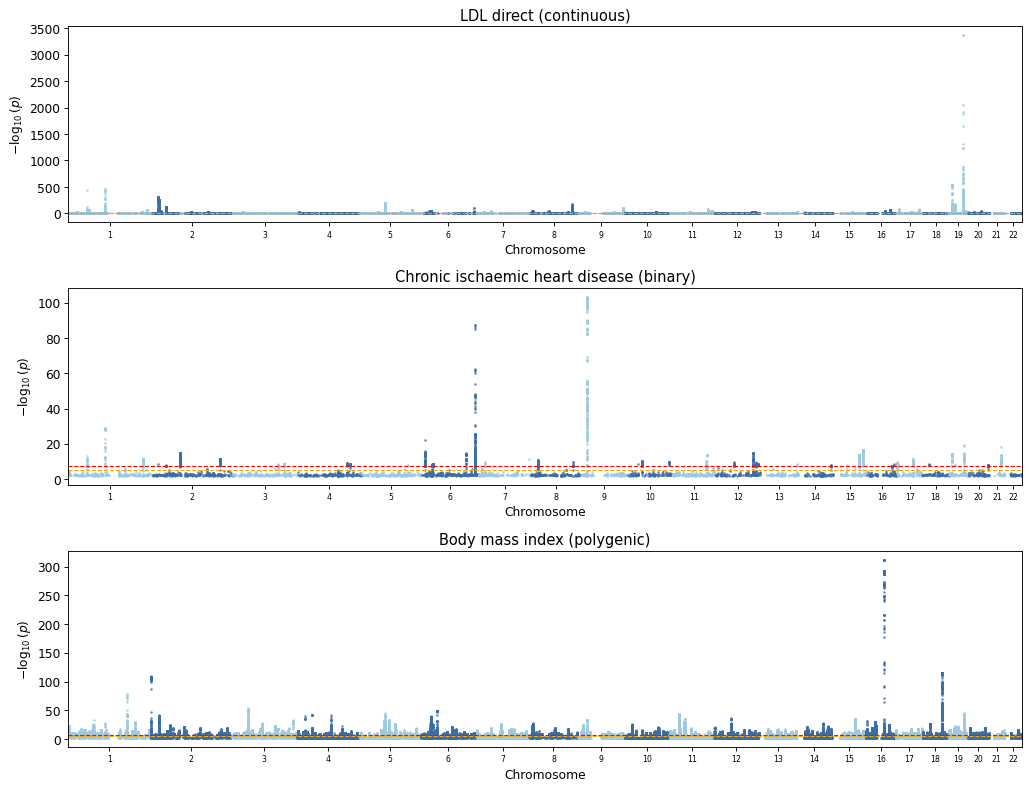

Q: Which trait is most polygenic (most independent towers genome-wide)?


In [2]:
# ── Exercise 1.1: Build a genome-wide Manhattan plot (provided) ──────────────
# We now use REAL Pan-UKB summary statistics (LDL, CAD, BMI) across all
# chromosomes. Each trait dict `real[t]` has: chrom, pos, maf, beta, se, nlog10p.
# NOTE: p-values are stored as nlog10p = -log10(p) already (avoids underflow at
# the extreme tail), so you do NOT need to recompute -log10(p).
# To lay out all chromosomes on one axis we add a cumulative offset per chromosome.

def manhattan_plot(chrom, pos, nlog10p, title='Manhattan plot', ax=None, thresh_plot=2.0):
    """
    chrom    : (M,) chromosome (1..22)
    pos      : (M,) base-pair position within chromosome
    nlog10p  : (M,) -log10(p)
    thresh_plot : only plot variants with -log10(p) >= this (declutter; p<1e-2 dropped)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(13, 4))
    keep = nlog10p >= thresh_plot
    chrom, pos, y = chrom[keep], pos[keep], nlog10p[keep]

    # Build a cumulative x-offset so chromosomes sit side by side
    offset, xticks, xlabels, x = 0, [], [], np.zeros(len(pos))
    shades = ['#3b6ea5', '#9ecae1']                      # alternate two shades per chromosome
    for c in range(1, 23):
        m = chrom == c
        if not m.any():
            continue
        x[m] = pos[m] + offset
        cmax = pos[m].max()
        xticks.append(offset + cmax / 2); xlabels.append(str(c))
        # Colour this chromosome's points (alternating shades) and scatter; thin dense
        # chromosomes with the provided _thin() helper so the figure stays light.
        mi = np.where(m)[0]; sel = mi[_thin(len(mi), k=2500, seed=c)]
        ax.scatter(x[sel], y[sel], s=2, alpha=0.6, color=shades[c % 2], rasterized=True)
        offset += cmax

    # Genome-wide (5e-8) and suggestive (1e-5) significance thresholds
    ax.axhline(-np.log10(5e-8), color='red',    linestyle='--', linewidth=1, label='5×10⁻⁸')
    ax.axhline(-np.log10(1e-5), color='orange', linestyle='--', linewidth=1, label='1×10⁻⁵')

    ax.set_xticks(xticks); ax.set_xticklabels(xlabels, fontsize=7)
    ax.set_xlabel('Chromosome'); ax.set_ylabel(r'$-\log_{10}(p)$')
    ax.set_title(title); ax.set_xlim(0, offset)
    return ax

fig, axes = plt.subplots(3, 1, figsize=(13, 10))
for ax, t in zip(axes, REAL_TRAITS):
    manhattan_plot(real[t]['chrom'], real[t]['pos'], real[t]['nlog10p'],
                   title=f"{REAL_LABELS[t]}", ax=ax)
plt.tight_layout(); plt.show()
print("Q: Which trait is most polygenic (most independent towers genome-wide)?")


## Part 2: The QQ Plot and Lambda GC

A **QQ (quantile-quantile) plot** compares the observed distribution of $-\log_{10}(p)$
to what we'd expect under the null (uniform distribution).

- **On the null diagonal** ($y = x$): observed ≈ expected — no inflation or deflation.
- **Above the diagonal**: more significant p-values than expected — could be true signal, population stratification, or model miscalibration.
- **Below the diagonal**: conservative p-values (uncommon).

**Lambda GC** ($\lambda_{GC}$) summarises inflation as a single number:
$$\lambda_{GC} = \frac{\text{median}(\chi^2_{obs})}{\text{expected median of } \chi^2_1}$$
where the expected median of $\chi^2_1 \approx 0.4549$.


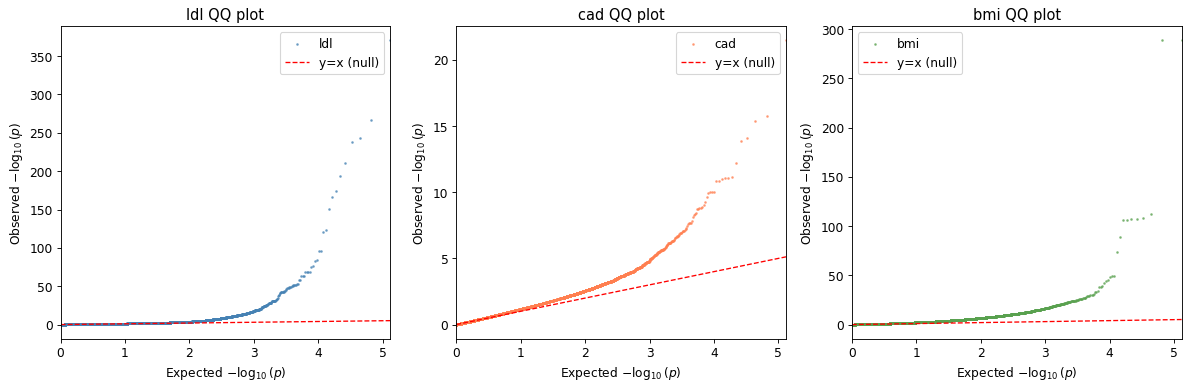

In [3]:
def qq_plot(nlog10p, label='', ax=None, color='steelblue'):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    n = len(nlog10p)
    obs = np.sort(nlog10p)                       # ascending observed -log10(p)
    exp = -np.log10(np.arange(n, 0, -1) / (n + 1))  # ascending expected -log10(p)
    d = np.unique(np.r_[_thin(n, k=6000), np.where(obs >= 2)[0]])  # thin bulk, keep tail
    ax.scatter(exp[d], obs[d], s=2, alpha=0.6, color=color, label=label)
    exp_max = -np.log10(1.0 / (n + 1))
    ax.plot([0, exp_max], [0, exp_max], 'r--', linewidth=1.2, label='y=x (null)')
    ax.set_xlim(0, exp_max)
    if label:
        ax.legend()
    ax.set_xlabel(r'Expected $-\log_{10}(p)$'); ax.set_ylabel(r'Observed $-\log_{10}(p)$')
    return ax

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, t, col in zip(axes, REAL_TRAITS, ['steelblue', 'coral', '#59a14f']):
    qq_plot(real[t]['nlog10p'][real[t]['rand']], label=t, ax=ax, color=col)
    ax.set_title(f'{t} QQ plot')
plt.tight_layout(); plt.show()


In [4]:
def lambda_gc(nlog10p):
    p    = np.power(10.0, -np.clip(nlog10p, 0, 300))
    chi2 = stats.chi2.isf(np.clip(p, 1e-300, 1), df=1)
    return np.median(chi2) / stats.chi2.ppf(0.5, df=1)   # expected median ≈ 0.4549

for t in REAL_TRAITS:
    lam = lambda_gc(real[t]['nlog10p'][real[t]['rand']])
    print(f"Lambda GC — {t:6s}: {lam:.3f}")


Lambda GC — ldl   : 1.355


Lambda GC — cad   : 1.196


Lambda GC — bmi   : 2.197


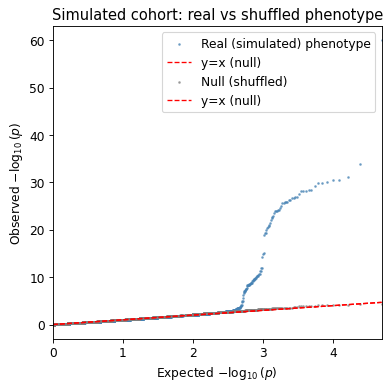

Lambda GC (null): 1.031  ← should be ≈ 1.0


In [5]:
# ── Sanity check: QQ plot under the null (simulated cohort) ──────────────────
# The real traits above show inflation from genuine polygenic signal. To see what
# NO signal looks like, we go back to the SIMULATED individual-level data and shuffle
# the phenotype to destroy any genotype-phenotype relationship, then re-run GWAS.
# The QQ plot should lie on the diagonal and lambda GC ≈ 1.0.

def qq_from_pvals(pvals, label='', ax=None, color='steelblue'):
    """Wrapper: QQ plot from raw p-values (simulated GWAS returns p, not -log10 p)."""
    return qq_plot(-np.log10(np.clip(pvals, 1e-300, 1)), label=label, ax=ax, color=color)

np.random.seed(0)
y_null = y_cont.copy(); np.random.shuffle(y_null)
_, _, pvals_null = run_gwas(y_null, G_qc, covars)

fig, ax = plt.subplots(figsize=(5, 5))
qq_from_pvals(pvals_cont, label='Real (simulated) phenotype', ax=ax, color='steelblue')
qq_from_pvals(pvals_null, label='Null (shuffled)', ax=ax, color='grey')
ax.set_title('Simulated cohort: real vs shuffled phenotype'); ax.legend()
plt.tight_layout(); plt.show()

lambda_null = np.median(stats.chi2.isf(np.clip(pvals_null,1e-300,1),df=1)) / stats.chi2.ppf(0.5,df=1)
print(f"Lambda GC (null): {lambda_null:.3f}  ← should be ≈ 1.0")


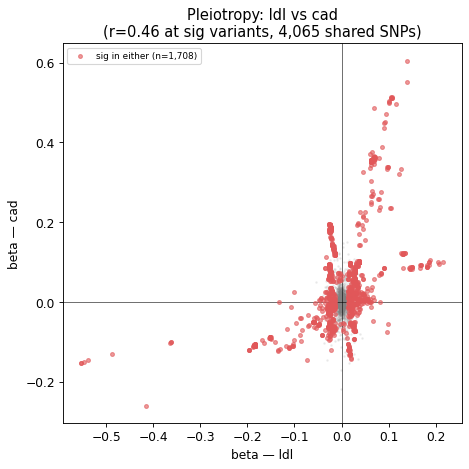

Q: LDL and CAD are causally linked — does the LDL–CAD beta cloud tilt positive?
Q: A variant with a large LDL effect but near-zero CAD effect — what does that imply?


In [6]:
# ── Pleiotropy: signed-beta scatter for LDL vs CAD ────────────────────────────
# A pleiotropy scatter plots the signed effect size (beta) of one trait vs another,
# for variants present in BOTH GWAS. Shared genetic effects show up as a tilted cloud.
# LDL and CAD are causally linked, so we expect their effect sizes to be correlated.

def merge_betas(ta, tb):
    """Align two real traits on chrom:pos; return (beta_a, beta_b, sig_a, sig_b)."""
    da, db = real[ta], real[tb]
    key_a = da['chrom'].astype(np.int64) * 10**9 + da['pos']
    key_b = db['chrom'].astype(np.int64) * 10**9 + db['pos']
    common, ia, ib = np.intersect1d(key_a, key_b, return_indices=True)
    return (da['beta'][ia], db['beta'][ib],
            da['sig'][ia],  db['sig'][ib], len(common))

trait_a, trait_b = 'ldl', 'cad'
beta_a, beta_b, sig_a, sig_b, n_common = merge_betas(trait_a, trait_b)
sig = sig_a | sig_b

fig, ax = plt.subplots(figsize=(6, 6))
ns = np.where(~sig)[0]; ns = ns[_thin(len(ns), k=8000)]          # thin grey cloud for display
ax.scatter(beta_a[ns], beta_b[ns], s=2, alpha=0.1, color='grey', rasterized=True)
si = np.where(sig)[0]; si = si[_thin(len(si), k=6000, seed=2)]   # thin significant points
ax.scatter(beta_a[si], beta_b[si], s=12, alpha=0.6, color='#e15759', zorder=5,
           label=f'sig in either (n={int(sig.sum()):,})')
ax.axhline(0, color='black', lw=0.5); ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel(f'beta — {trait_a}'); ax.set_ylabel(f'beta — {trait_b}')
r = np.corrcoef(beta_a[sig], beta_b[sig])[0, 1] if sig.sum() > 2 else float('nan')
ax.set_title(f'Pleiotropy: {trait_a} vs {trait_b}\n'
             f'(r={r:.2f} at sig variants, {n_common:,} shared SNPs)')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print("Q: LDL and CAD are causally linked — does the LDL–CAD beta cloud tilt positive?")
print("Q: A variant with a large LDL effect but near-zero CAD effect — what does that imply?")


---

## Challenge Questions


### Challenge 1: QQ plot with 95% confidence interval — ~10 min

Under the null, the $k$-th smallest p-value follows a Beta$(k, n-k+1)$ distribution.
Use `scipy.stats.beta.ppf` to add a 95% confidence band to the QQ plot.

To see what the band is *for*, we draw two QQ plots side by side: a genuinely **near-null** trait
(the shuffled simulated phenotype from the null-QQ cell — its points should sit inside the band),
and the **real BMI** GWAS (a hugely polygenic trait — its points should shoot far above the band).


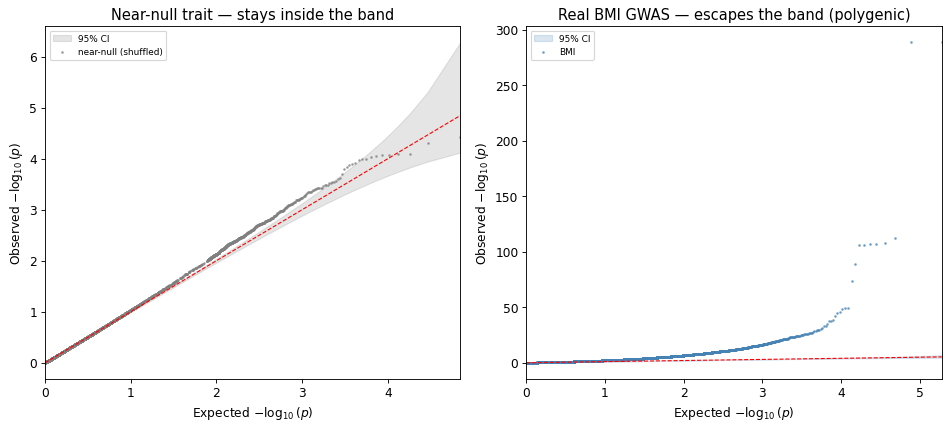

In [7]:
def qq_plot_ci(nlog10p, ax=None, color='steelblue', ci_alpha=0.05, label=''):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    n = len(nlog10p); observed_sorted = np.sort(nlog10p); ks = np.arange(n, 0, -1)
    d = np.unique(np.r_[_thin(n, k=4000), np.where(observed_sorted >= 2)[0]])  # thin bulk, keep tail
    observed_sorted, ks = observed_sorted[d], ks[d]
    expected_median = stats.beta.ppf(0.5, ks, n-ks+1)
    ci_lower        = stats.beta.ppf(ci_alpha/2, ks, n-ks+1)
    ci_upper        = stats.beta.ppf(1 - ci_alpha/2, ks, n-ks+1)
    ax.fill_between(-np.log10(expected_median), -np.log10(ci_upper), -np.log10(ci_lower),
                    alpha=0.2, color=color, label='95% CI')
    ax.scatter(-np.log10(expected_median), observed_sorted, s=2, alpha=0.6, color=color, label=label)
    expected_max = (-np.log10(expected_median)).max()
    ax.plot([0, expected_max], [0, expected_max], 'r--', linewidth=1.0); ax.set_xlim(0, expected_max)
    ax.set_xlabel(r'Expected $-\log_{10}(p)$'); ax.set_ylabel(r'Observed $-\log_{10}(p)$')
    ax.legend(fontsize=8); return ax

nlog10p_null = -np.log10(np.clip(pvals_null, 1e-300, 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
qq_plot_ci(nlog10p_null, ax=axes[0], color='grey', label='near-null (shuffled)')
axes[0].set_title('Near-null trait — stays inside the band')
qq_plot_ci(real['bmi']['nlog10p'][real['bmi']['rand']], ax=axes[1], color='steelblue', label='BMI')
axes[1].set_title('Real BMI GWAS — escapes the band (polygenic)')
plt.tight_layout(); plt.show()


### Challenge 2: MAF-stratified QQ plot — ~8 min

Are rare variants (low MAF) better or worse behaved than common variants?
Stratify the real BMI variants into MAF bins and overlay QQ plots (random subset).


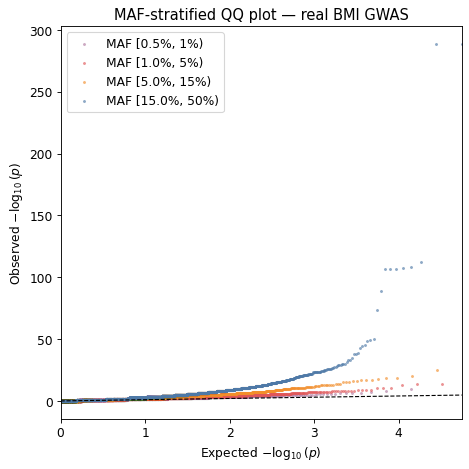

In [8]:
sub   = real['bmi']['rand']
maf_h = real['bmi']['maf'][sub]
nlp_h = real['bmi']['nlog10p'][sub]

def qq_coords(nlog10p):
    obs  = np.sort(nlog10p); m = len(obs)
    exp  = -np.log10(np.arange(m, 0, -1) / (m + 1))
    keep = np.unique(np.r_[_thin(m, k=4000), np.where(obs >= 2)[0]])
    return exp[keep], obs[keep]

maf_bins = [(0.005, 0.01), (0.01, 0.05), (0.05, 0.15), (0.15, 0.50)]
colours  = ['#b07aa1', '#e15759', '#f28e2b', '#4e79a7']

fig, ax = plt.subplots(figsize=(6, 6)); exp_max = 0
for (lo, hi), col in zip(maf_bins, colours):
    mask = (maf_h >= lo) & (maf_h < hi)
    if mask.sum() < 10:
        continue
    exp, obs = qq_coords(nlp_h[mask])
    ax.scatter(exp, obs, s=3, alpha=0.5, color=col, label=f'MAF [{lo:.1%}, {hi:.0%})')
    exp_max = max(exp_max, exp.max())
ax.plot([0, exp_max], [0, exp_max], 'k--', linewidth=1); ax.set_xlim(0, exp_max)
ax.set_title('MAF-stratified QQ plot — real BMI GWAS')
ax.set_xlabel(r'Expected $-\log_{10}(p)$'); ax.set_ylabel(r'Observed $-\log_{10}(p)$')
ax.legend(); plt.tight_layout(); plt.show()


### Challenge 3: Trumpet plot and power curves — ~12 min

A **trumpet plot** shows the signed effect size ($\hat{\beta}$) vs. MAF for each variant.
The "trumpet" shape emerges because the power curves form a ±symmetric band:
variants outside the band are detectable, those inside are below the noise floor.
Points beyond the band on the left (rare variants) require large effects to be detected.

We use the **real LDL GWAS** (Pan-UKB, EUR, N≈400k). Real discovered variants should sit
on or beyond the power band for a study of that size.


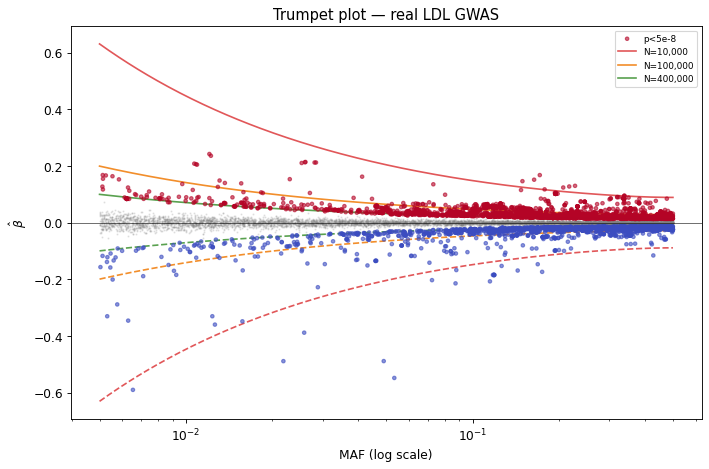

In [9]:
def power_curve(n, maf_arr, alpha=5e-8):
    from scipy.stats import norm
    ncp_target = (norm.isf(alpha/2) + norm.isf(0.2))**2
    return np.sqrt(ncp_target / (n * 2 * maf_arr * (1-maf_arr) + 1e-8))

maf_l, beta_l = real['ldl']['maf'], real['ldl']['beta']
sig_l, rnd_l  = real['ldl']['sig'], real['ldl']['rand']
maf_grid = np.logspace(np.log10(0.005), np.log10(0.5), 300)

fig, ax = plt.subplots(figsize=(9, 6))
bgi = np.where(rnd_l & ~sig_l)[0]; bgi = bgi[_thin(len(bgi), k=8000)]   # thin background
ax.scatter(maf_l[bgi], beta_l[bgi], s=1, alpha=0.15, color='grey', rasterized=True)
si = np.where(sig_l)[0]; si = si[_thin(len(si), k=6000, seed=1)]        # thin significant pts
ax.scatter(maf_l[si], beta_l[si], s=10, alpha=0.6,
           c=np.sign(beta_l[si]), cmap='coolwarm', vmin=-1, vmax=1, zorder=5, label='p<5e-8')
for n_s, col in [(10_000,'#e15759'),(100_000,'#f28e2b'),(400_000,'#59a14f')]:
    pb = power_curve(n_s, maf_grid)
    ax.plot(maf_grid, +pb, color=col, linewidth=1.5, label=f'N={n_s:,}')
    ax.plot(maf_grid, -pb, color=col, linewidth=1.5, linestyle='--')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xscale('log')
ax.set_xlabel('MAF (log scale)'); ax.set_ylabel(r'$\hat{{\beta}}$')
ax.set_title('Trumpet plot — real LDL GWAS'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


### Challenge 4: GWAS vs exome — a BMI Miami plot — ~12 min

A **Miami plot** stacks two association scans back-to-back on one position axis: here the **Pan-UKB
common-variant GWAS** for BMI points **up**, and **Genebass whole-exome single-variant** results for
BMI point **down**. The common-variant GWAS tags broad regulatory regions; the exome scan pinpoints
**coding** variants in genes.

The Pan-UKB GWAS has been **lifted from GRCh37 to GRCh38** (see `fetch_gene_models.py`), so it shares
**one coordinate system** with the Genebass exome data and with a **gene / coding-exon track** drawn
beneath the plot. We then **zoom into the _ADCY9_ locus** (chr16p13.3, ~3.9–4.2 Mb), a BMI-associated
region covered by **both** assays, and draw the gene models — *CREBBP*, *ADCY9*, *SRL* — each on its own
lane underneath. The contrast to look for: the **exome (coding) variants sit squarely on coding exons**
(boxes in the track) — that is all an exome assay can see — while the **common-variant GWAS variants are
scattered indiscriminately** across the whole locus, mostly in introns. After plotting, compare the
**effect sizes of significant exome variants by consequence** (synonymous / missense / pLoF).


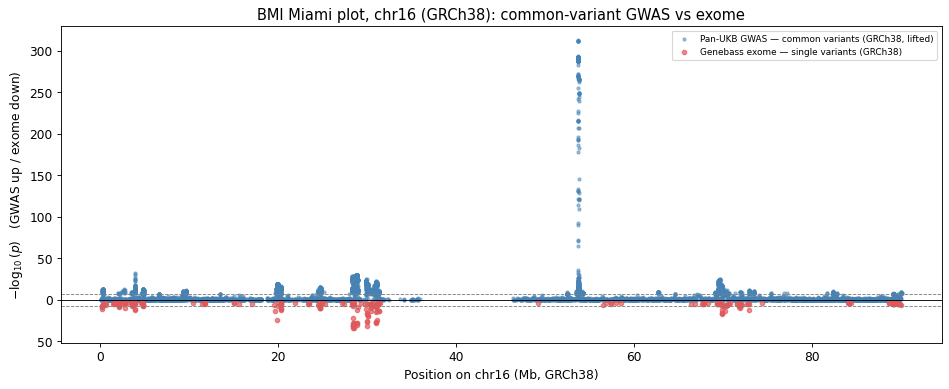

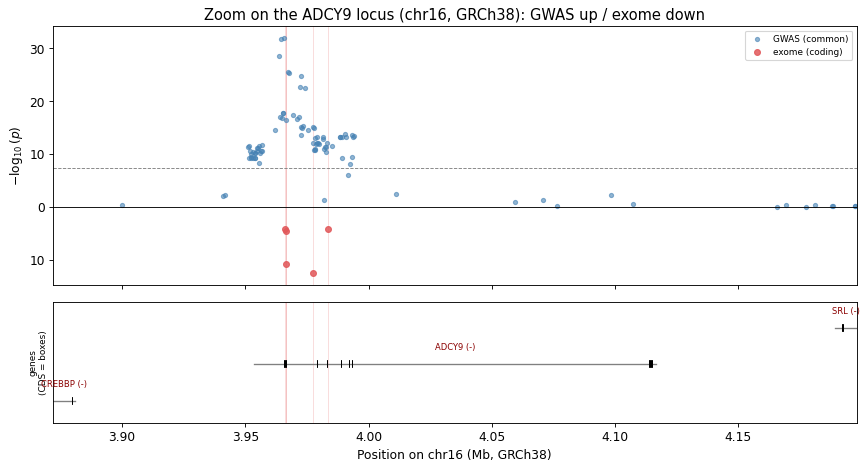

In [10]:
MIAMI_CHROM = 16
gwas_pos_mb  = genemodels['gw_pos38'] / 1e6          # GWAS lifted GRCh37->GRCh38
gwas_nlog10p = genemodels['gw_nlog10p']
exome_on_chrom = genebass[genebass['chrom'] == str(MIAMI_CHROM)]
exome_pos_mb   = exome_on_chrom['pos'].values / 1e6
exome_nlog10p  = exome_on_chrom['nlog10p'].values

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(gwas_pos_mb, gwas_nlog10p, s=8, alpha=0.5, color='steelblue',
           label='Pan-UKB GWAS — common variants (GRCh38, lifted)')
ax.scatter(exome_pos_mb, -exome_nlog10p, s=16, alpha=0.7, color='#e15759',   # KEY: exome points DOWN
           label='Genebass exome — single variants (GRCh38)')
ax.axhline(0, color='black', lw=0.8)
ax.axhline(-np.log10(5e-8), color='grey', ls='--', lw=0.8)
ax.axhline( np.log10(5e-8), color='grey', ls='--', lw=0.8)
ax.set_yticklabels([f'{abs(t):.0f}' for t in ax.get_yticks()])
ax.set_xlabel(f'Position on chr{MIAMI_CHROM} (Mb, GRCh38)')
ax.set_ylabel(r'$-\log_{10}(p)$   (GWAS up / exome down)')
ax.set_title(f'BMI Miami plot, chr{MIAMI_CHROM} (GRCh38): common-variant GWAS vs exome')
ax.legend(fontsize=8, loc='upper right'); plt.tight_layout(); plt.show()

def gene_track(ax_track, x0_mb, x1_mb):
    """Draw chr16 genes overlapping [x0_mb, x1_mb], each on its own lane:
    thin grey line = gene body (mostly introns); black boxes = coding exons (CDS)."""
    names = genemodels['gene_name']
    vis = [gi for gi in range(len(names))
           if genemodels['gene_end'][gi] / 1e6 >= x0_mb and genemodels['gene_start'][gi] / 1e6 <= x1_mb]
    vis.sort(key=lambda gi: genemodels['gene_start'][gi])
    for lane, gi in enumerate(vis):
        gs, ge = genemodels['gene_start'][gi] / 1e6, genemodels['gene_end'][gi] / 1e6
        strand = genemodels['gene_strand'][gi]
        ax_track.plot([max(gs, x0_mb), min(ge, x1_mb)], [lane, lane], color='grey', lw=1.2, zorder=1)
        for g2, s, e in zip(genemodels['cds_gi'], genemodels['cds_start'], genemodels['cds_end']):
            if g2 == gi:
                ax_track.plot([s / 1e6, e / 1e6], [lane, lane], color='black',
                              lw=7, solid_capstyle='butt', zorder=2)
        mid = (max(gs, x0_mb) + min(ge, x1_mb)) / 2
        ax_track.text(mid, lane + 0.34, f"{names[gi]} ({strand})", ha='center', va='bottom',
                      fontsize=7.5, color='darkred')
    ax_track.set_yticks([]); ax_track.set_ylim(-0.6, max(len(vis) - 1, 0) + 0.7)
    ax_track.set_xlim(x0_mb, x1_mb)

_adcy9 = list(genemodels['gene_name']).index('ADCY9')
a_s, a_e = genemodels['gene_start'][_adcy9] / 1e6, genemodels['gene_end'][_adcy9] / 1e6
pad = 0.5 * (a_e - a_s); ZOOM = (a_s - pad, a_e + pad)

fig, (axz, axg) = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1.4]})
zg = (gwas_pos_mb >= ZOOM[0]) & (gwas_pos_mb <= ZOOM[1])
ze = (exome_pos_mb >= ZOOM[0]) & (exome_pos_mb <= ZOOM[1])
axz.scatter(gwas_pos_mb[zg], gwas_nlog10p[zg], s=14, alpha=0.6, color='steelblue', label='GWAS (common)')
axz.scatter(exome_pos_mb[ze], -exome_nlog10p[ze], s=28, alpha=0.85, color='#e15759', label='exome (coding)')
for x in exome_pos_mb[ze]:
    axz.axvline(x, color='#e15759', lw=0.6, alpha=0.3, zorder=0)
    axg.axvline(x, color='#e15759', lw=0.6, alpha=0.3, zorder=0)
axz.axhline(0, color='black', lw=0.8); axz.axhline(-np.log10(5e-8), color='grey', ls='--', lw=0.8)
axz.set_yticklabels([f'{abs(t):.0f}' for t in axz.get_yticks()])
axz.set_ylabel(r'$-\log_{10}(p)$'); axz.legend(fontsize=8, loc='upper right')
axz.set_title('Zoom on the ADCY9 locus (chr16, GRCh38): GWAS up / exome down')
gene_track(axg, *ZOOM)
axg.set_xlabel('Position on chr16 (Mb, GRCh38)'); axg.set_ylabel('genes\n(CDS = boxes)', fontsize=8)
plt.tight_layout(); plt.show()
# The exome variants sit ON coding exons (that is all exome sequencing assays); the common-variant
# GWAS variants are scattered across the locus, mostly intronic, tagging the signal via LD.


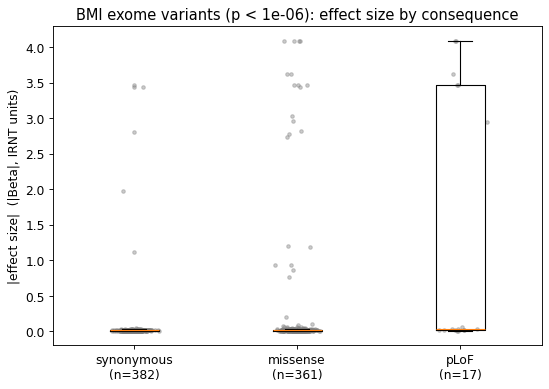

  synonymous : n= 382, median |beta| = 0.0149
  missense   : n= 361, median |beta| = 0.0167
  pLoF       : n=  17, median |beta| = 0.0309


In [11]:
EXOME_SIG = 1e-6
significant_exome = genebass[genebass['pval'] < EXOME_SIG].copy()
PLOF = {'stop_gained', 'frameshift_variant', 'splice_donor_variant',
        'splice_acceptor_variant', 'start_lost'}
def consequence_group(csq):
    if csq in PLOF:                 return 'pLoF'
    if csq == 'missense_variant':   return 'missense'
    if csq == 'synonymous_variant': return 'synonymous'
    return 'other'
significant_exome['group'] = significant_exome['CSQ'].map(consequence_group)

groups = ['synonymous', 'missense', 'pLoF']
abs_beta_by_group = [ significant_exome.loc[significant_exome['group'] == g, 'beta'].abs().values
                      for g in groups ]

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(abs_beta_by_group, showfliers=False)
ax.set_xticks(range(1, len(groups) + 1))
ax.set_xticklabels([f'{g}\n(n={len(a)})' for g, a in zip(groups, abs_beta_by_group)])
for i, a in enumerate(abs_beta_by_group, start=1):
    ax.scatter(np.random.default_rng(i).normal(i, 0.05, len(a)), a, s=10, alpha=0.4, color='grey')
ax.set_ylabel('|effect size|  (|Beta|, IRNT units)')
ax.set_title(f'BMI exome variants (p < {EXOME_SIG:g}): effect size by consequence')
plt.tight_layout(); plt.show()
for g, a in zip(groups, abs_beta_by_group):
    print(f"  {g:11s}: n={len(a):4d}, median |beta| = {np.median(a):.4f}")
# pLoF > missense > synonymous: disrupting the protein has larger phenotypic consequences than
# a synonymous change, which is (mostly) silent.


### Challenge 5: Bonferroni vs Šidák — ~8 min

The genome-wide threshold $5\times10^{-8}$ is essentially a **Bonferroni** correction: for a
family-wise error rate $\alpha_{FW}$ over $C$ tests, use per-test $\alpha_{PT}=\alpha_{FW}/C$
(with $\alpha_{FW}=0.05$, $C\approx10^6$ independent common variants).

**Šidák** is exact *under independence*. With $C$ independent tests each at per-test threshold
$\alpha_{PT}$, the probability of **no** false positive is $(1-\alpha_{PT})^{C}$, so the
family-wise error rate is

$$\alpha_{FW} = 1 - (1-\alpha_{PT})^{C}.$$

**Your job: solve this equation for the per-test threshold $\alpha_{PT}$** (in terms of
$\alpha_{FW}$ and $C$), implement it, and compare to Bonferroni ($\alpha_{FW}/C$) across a range of
$C$ — including the **ratio** of the two thresholds (see Abdi, 2007).


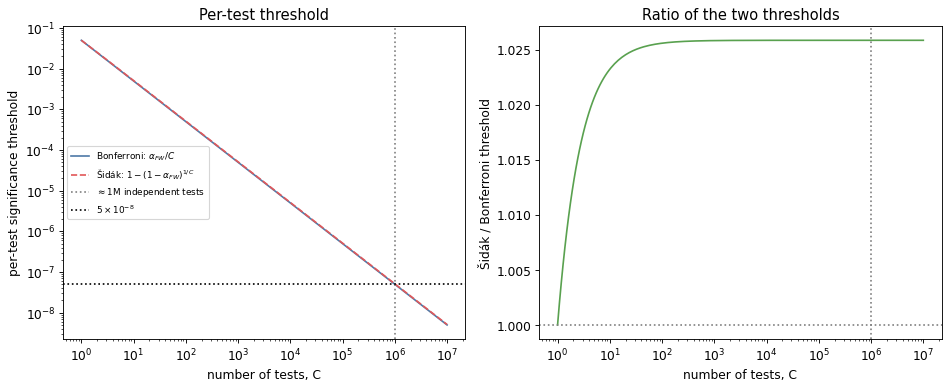

At C=1e6:  Bonferroni=4.829e-08, Šidák=4.954e-08, ratio=1.0259


In [12]:
alpha_familywise = 0.05
C = np.logspace(0, 7, 200)

bonferroni_threshold = alpha_familywise / C
sidak_threshold = 1 - (1 - alpha_familywise)**(1.0 / C)
ratio = sidak_threshold / bonferroni_threshold

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.loglog(C, bonferroni_threshold, color='#4e79a7', label=r'Bonferroni: $\alpha_{FW}/C$')
ax1.loglog(C, sidak_threshold, '--', color='#e15759', label=r'Šidák: $1-(1-\alpha_{FW})^{1/C}$')
ax1.axvline(1e6, color='grey', ls=':', label=r'$\approx$1M independent tests')
ax1.axhline(5e-8, color='black', ls=':', label=r'$5\times10^{-8}$')
ax1.set_xlabel('number of tests, C'); ax1.set_ylabel('per-test significance threshold')
ax1.set_title('Per-test threshold'); ax1.legend(fontsize=8)
ax2.semilogx(C, ratio, color='#59a14f')
ax2.axhline(1.0, color='grey', ls=':')
ax2.axvline(1e6, color='grey', ls=':')
ax2.set_xlabel('number of tests, C'); ax2.set_ylabel('Šidák / Bonferroni threshold')
ax2.set_title('Ratio of the two thresholds')
plt.tight_layout(); plt.show()

at_1e6 = np.argmin(np.abs(C - 1e6))
print(f"At C=1e6:  Bonferroni={bonferroni_threshold[at_1e6]:.3e}, "
      f"Šidák={sidak_threshold[at_1e6]:.3e}, ratio={ratio[at_1e6]:.4f}")
# Šidák is always slightly LESS conservative (ratio > 1), most so at small C; as C grows
# 1-(1-a)^(1/C) ≈ a/C, so the ratio tends to 1 and the practical difference vanishes.
